# Gap-filling head time series using Pastas

*Raoul Collenteur, Hydroconsult, 2026*

In [1]:
import pandas as pd
import pastas as ps
import matplotlib.pyplot as plt

ps.show_versions()

Pastas     : 2.0.0
Python     : 3.13.11
Numpy      : 2.4.3
Pandas     : 2.3.1
Scipy      : 1.17.1
Matplotlib : 3.10.8
Numba      : 0.64.0



In [2]:
head = pd.read_csv(
    "data/head_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()

# Create a gap in the head data
head_gap = head.copy()
head_gap.loc["1996"] = pd.NA
head_gap = head_gap.dropna()

prec = pd.read_csv(
    "data/rain_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()
evap = pd.read_csv(
    "data/evap_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()

# data = ps.load_dataset("collenteur_2019")
# head = data["head"].squeeze()

# head_gap = head.iloc[::14].copy()
# head_gap.loc["2007"] = pd.NA
# head_gap = head_gap.dropna()
# prec = data["rain"].asfreq("D").fillna(0)
# evap = data["evap"].asfreq("D").interpolate()

<Axes: xlabel='date'>

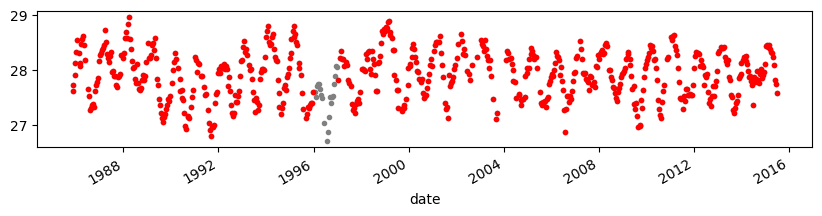

In [3]:
head.plot(marker=".", color="gray", linestyle="None", label="head", figsize=(10, 2))
head_gap.plot(marker=".", color="red", linestyle="None", label="head with gap")

In [4]:
ml = ps.Model(head_gap)
sm = ps.RechargeModel(prec=prec, evap=evap, rfunc=ps.Exponential(), name="rch")
ml.add_stressmodel(sm)
ml.solve()
ml.add_noisemodel(ps.ArNoiseModel())
ml.solve(initial=False)

Fit report head                     Fit Statistics
nfev     12                     EVP          93.51
nobs     623                    R2            0.94
noise    False                  RMSE          0.11
tmin     1985-11-14 00:00:00    AICc      -2756.77
tmax     2015-06-28 00:00:00    BIC       -2739.10
freq     D                      Obj           3.68
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No

Parameters (4 optimized)
               optimal     initial  vary
rch_A       602.818553  215.674528  True
rch_a       165.666551   10.000000  True
rch_f        -1.549188   -1.000000  True
constant_d   28.157068   27.912729  True
Fit report head                     Fit Statistics
nfev     10                     EVP          93.09
nobs     623                    R2            0.93
noise    True                   RMSE          0.11
tmin     1985-11-14 00:00:00    AICc      -3169.32
tmax     2015-06-28 00:00:00    BIC       -3147.25
freq

<Axes: xlabel='date', ylabel='Head'>

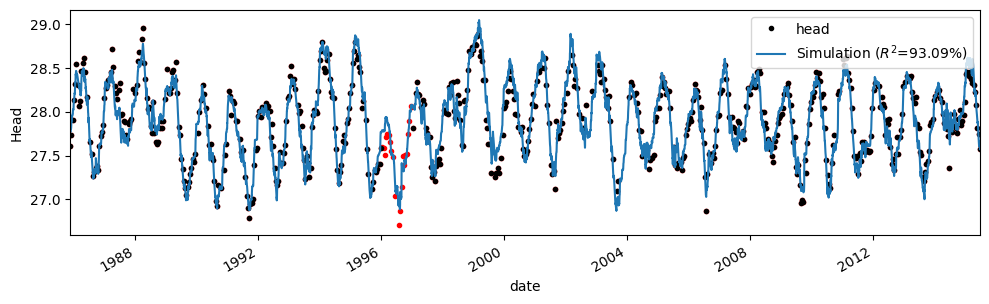

In [5]:
ax = ml.plot(figsize=(10, 3))
head.plot(marker=".", color="red", linestyle="None", label="head", ax=ax, zorder=-1)

In [6]:
head_filled = ps.gap_fill(
    head_gap.asfreq("D"), ml, tmin=head.index[0], tmax=head.index[-1], alpha=0.05
)

Text(0, 0.5, 'head [m]')

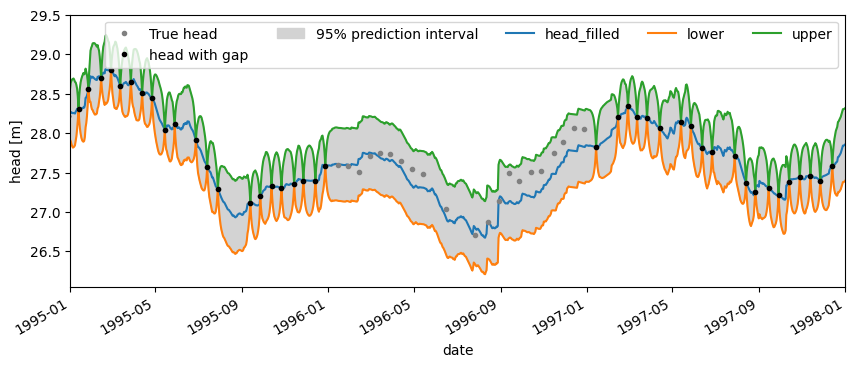

In [17]:
ax = head.plot(
    marker=".", color="gray", linestyle="None", label="True head", figsize=(10, 4)
)
head_gap.plot(marker=".", color="k", linestyle="None", label="head with gap")
# Fill between
ax.fill_between(
    head_filled.index,
    head_filled["lower"],
    head_filled["upper"],
    color="lightgray",
    label="95% prediction interval",
    zorder=-2,
)

head_filled.plot(ax=ax, zorder=-1)
plt.xlim("1995", "1998")
# plt.xlim("2005", "2010")
plt.legend(ncol=5)
plt.ylabel("head [m]")

date
1985-11-14    27.61
1985-11-28    27.73
1985-12-14    27.91
1985-12-28    28.13
1986-01-13    28.32
              ...  
2015-04-28    28.23
2015-05-14    28.08
2015-05-28    27.82
2015-06-14    27.75
2015-06-28    27.57
Name: head, Length: 644, dtype: float64

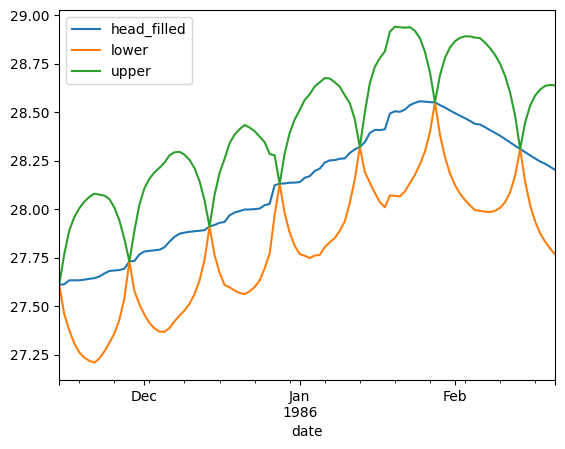

In [ ]:
head_filled.iloc[:100].plot(linestyle="-")
head  # .iloc[: head_filled.iloc[:100].index[-1]].plot()

In [9]:
ml.noise().std()

np.float64(0.07852839115535476)